# 03 — Animal-level rollup + stats-ready export shapes

Rolls the per-slice region readout (`cockpit_regions`, increment 2) up to the **animal**
level, stacks multiple animals/projects into one group-ready table, computes the full
engram-overlap metric family, and writes both a tidy LONG table and Prism-friendly WIDE
pivots (`cockpit_animal`, increment 3).

This notebook structurally enforces CLAUDE.md's stats convention -- *aggregate to the animal
level before any group comparison; sections are not independent.* Every number here is
**pooled from summed counts/areas, then recomputed** -- never a mean of per-slice ratios.

All logic lives in `cockpit_animal`; this notebook only calls module functions and displays
their output. **READ-ONLY** -- no QuPath launch, no detection pass, no writes inside any
project directory. Run in the `braian` env.

## PARAMS — the only cell you edit

In [1]:
PARAMS = {
    # QuPath project dir(s) to roll up (each holds pipeline.yml, results/). One project =
    # one exploratory animal run; two+ projects exercises D-2 stacking.
    "projects": [
        "/home/jflab/Analysis/M3 Hipp1 072326 7scene/M3 Hipp1 072326 7 Scene QuPath",
    ],

    # Regions for the readout. None -> all included leaves per project.
    "regions": ["CA1", "CA3", "DG", "PIR", "STRd"],

    # D-3 explicit group/condition mapping: {animal: group}. Empty -> group="unassigned"
    # (fine for a single-animal exploratory run; required before any group comparison).
    "groups": {
        # "M3-hipp1": "recall",
        # "wBA1-2_2-1": "control",
    },

    # D-1 role overrides. None -> resolved from pipeline.yml (role: key, else compartment
    # rule -- never marker declaration order).
    "tagged_marker": None,
    "activity_marker": None,

    # D-4 denominator source: "auto" (classifiable for 'both' rows when a percell export
    # exists, anchor count otherwise), "anchor", or "classifiable".
    "n_source": "auto",

    # D-2: raise (default) or stack on the shared marker set when projects declare
    # different marker sets.
    "stack_on_intersection": False,

    # Which hemisphere slice the WIDE pivots pick (the LONG table always keeps all three).
    "hemisphere": "both",

    # Where the long CSV + wide/ pivots land (gitignored).
    "out_dir": "/home/jflab/Analysis/results/animal/notebook",

    # Interpretation plots (section 5): region cap for the ranked figures.
    "top_n": 20,
    # Interpretation plots: evidence-guard (figure 3) de-emphasis threshold.
    "min_cells": 30,
    # Interpretation plots: also write PNGs to <out_dir>/figures/ next to the CSV.
    "save_figures": True,
}

import sys
from pathlib import Path

sys.path.insert(0, str(Path("/home/jflab/Analysis/scripts")))

# ipykernel in this env does not auto-activate the inline backend, so matplotlib
# falls back to the non-interactive Agg canvas and a figure would silently render
# nothing. Make it explicit (same idiom as 02_batch.ipynb).
%matplotlib inline

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cockpit_animal as ca
import cockpit_checks as cc
import cockpit_regions as creg

PROJECTS = [Path(p) for p in PARAMS["projects"]]
OUT_DIR = Path(PARAMS["out_dir"])
print(f"projects  : {[p.name for p in PROJECTS]}")
print(f"regions   : {PARAMS['regions'] or '(all included leaves)'}")
print(f"n_source  : {PARAMS['n_source']}   hemisphere: {PARAMS['hemisphere']}")
print(f"out_dir   : {OUT_DIR}")

projects  : ['M3 Hipp1 072326 7 Scene QuPath']
regions   : ['CA1', 'CA3', 'DG', 'PIR', 'STRd']
n_source  : auto   hemisphere: both
out_dir   : /home/jflab/Analysis/results/animal/notebook


## 1. Config panel — per project: markers, resolved roles, slice count

D-1 role resolution (config-derived, never positional) and the D-2 marker-set check, so a
mismatch is visible here before the rollup runs.

In [2]:
marker_sets = {}
for p in PROJECTS:
    config = creg.load_pipeline_config(p)
    roles = ca.resolve_roles(config, tagged=PARAMS["tagged_marker"], activity=PARAMS["activity_marker"])
    slices = cc.find_slices(p)
    marker_sets[p] = tuple(config.marker_names)
    print(f"{p.name}")
    print(f"  markers      : {config.marker_names}   Double+: {'yes' if config.emit_double else 'no'}")
    print(f"  tagged       : {roles.tagged}")
    print(f"  activity     : {roles.activity}")
    print(f"  slices       : {len(slices)}  ({', '.join(s.label for s in slices)})")
    print()

unique_sets = set(marker_sets.values())
if len(unique_sets) > 1:
    print(f"MARKER-SET MISMATCH across projects: {marker_sets}")
    print(f"  stack_on_intersection={PARAMS['stack_on_intersection']} "
          f"-- {'will stack on the shared set' if PARAMS['stack_on_intersection'] else 'rollup below will raise'}")
else:
    print(f"Marker set consistent across all projects: {sorted(unique_sets)[0] if unique_sets else '(none)'}")

M3 Hipp1 072326 7 Scene QuPath
  markers      : ['Fos', 'TdT']   Double+: yes
  tagged       : TdT
  activity     : Fos
  slices       : 7  (M3-hipp1_s1, M3-hipp1_s2, M3-hipp1_s3, M3-hipp1_s4, M3-hipp1_s5, M3-hipp1_s6, M3-hipp1_s7)

Marker set consistent across all projects: ('Fos', 'TdT')


## 2. Animal rollup — the long table

`n_slices` is the anti-pseudoreplication audit trail: it is always visible per animal/region
so a group comparison downstream (BraiAnalyse) can confirm it is aggregating animals, not
sections.

In [3]:
combined = ca.stack_animals(
    PROJECTS, regions=PARAMS["regions"], tagged=PARAMS["tagged_marker"],
    activity=PARAMS["activity_marker"], n_source=PARAMS["n_source"],
    stack_on_intersection=PARAMS["stack_on_intersection"])

combined = ca.apply_group_map(combined, PARAMS["groups"])

print(f"{len(combined):,} rows  |  animals: {sorted(combined['animal'].unique())}  "
      f"|  regions: {combined['region_acronym'].nunique()}")
display(combined[["group", "animal", "region_acronym", "hemisphere", "n_slices", "N_source", "N"]]
        .drop_duplicates().sort_values(["animal", "region_acronym", "hemisphere"]).head(20))

15 rows  |  animals: ['M3-hipp1']  |  regions: 5


           A zero here usually means the cells sit on a non-frontier intermediate annotation (increment 2's coverage caveat), NOT that the region is empty. Check cockpit_regions.coverage_report() before reporting these.


,group,animal,region_acronym,hemisphere,n_slices,N_source,N
0,unassigned,M3-hipp1,CA1,L,6,anchor_count,13534.0
1,unassigned,M3-hipp1,CA1,R,5,anchor_count,9206.0
2,unassigned,M3-hipp1,CA1,both,6,classifiable,22740.0
3,unassigned,M3-hipp1,CA3,L,6,anchor_count,12281.0
4,unassigned,M3-hipp1,CA3,R,6,anchor_count,9859.0
5,unassigned,M3-hipp1,CA3,both,6,classifiable,22139.0
6,unassigned,M3-hipp1,DG,L,6,anchor_count,5149.0
7,unassigned,M3-hipp1,DG,R,6,anchor_count,4657.0
8,unassigned,M3-hipp1,DG,both,6,classifiable,9806.0
9,unassigned,M3-hipp1,PIR,L,7,anchor_count,29797.0


## 3. Metric panel — the metric family, ordered by `overlap_above_chance`

`overlap_above_chance` is the PRIMARY chance-corrected metric (see the caveat panel below for
why it is DAPI-dependent). Pair metrics (reactivation/reverse/overlap/odds-ratios/jaccard) are
simply ABSENT -- not NaN -- for any project/stack whose resolved roles or intersection marker
set has fewer than two markers.

In [4]:
both = combined[combined["hemisphere"] == PARAMS["hemisphere"]].copy()

metric_cols = [c for c in ("tagging_rate", "activity_rate", "reactivation_rate", "reverse_rate",
                            "overlap_above_chance", "log2_odds_ratio", "log2_odds_ratio_hc",
                            "jaccard") if c in both.columns]
print(f"Metric columns present: {metric_cols}")

if "overlap_above_chance" in both.columns:
    ranked = both.sort_values("overlap_above_chance", ascending=False)
else:
    ranked = both.sort_values(metric_cols[0] if metric_cols else "region_acronym", ascending=False)

display(ranked[["group", "animal", "region_acronym", "n_slices", "N", "N_source"] + metric_cols]
        .head(20))

Metric columns present: ['tagging_rate', 'activity_rate', 'reactivation_rate', 'reverse_rate', 'overlap_above_chance', 'log2_odds_ratio', 'log2_odds_ratio_hc', 'jaccard']


,group,animal,region_acronym,n_slices,N,N_source,tagging_rate,activity_rate,reactivation_rate,reverse_rate,overlap_above_chance,log2_odds_ratio,log2_odds_ratio_hc,jaccard
2,unassigned,M3-hipp1,CA1,6,22740.0,classifiable,0.021724,0.088830,0.376518,0.092079,4.238626,2.748724,2.749899,0.079897
8,unassigned,M3-hipp1,DG,6,9806.0,classifiable,0.088925,0.029166,0.105505,0.321678,3.617406,2.409736,2.413000,0.086304
5,unassigned,M3-hipp1,CA3,6,22139.0,classifiable,0.035187,0.066625,0.192555,0.101695,2.890146,1.850361,1.853507,0.071293
11,unassigned,M3-hipp1,PIR,7,57857.0,classifiable,0.052699,0.271946,0.644146,0.124825,2.368650,2.431532,2.431199,0.116773
14,unassigned,M3-hipp1,STRd,7,0.0,classifiable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Export — long CSV + wide pivots

Delegates entirely to `cockpit_animal.write_long_csv` / `write_wide_pivots` -- no analysis
logic here, only the write + printed paths.

In [5]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

long_path = ca.write_long_csv(combined, OUT_DIR / "animal_region_long.csv")
print(f"long table -> {long_path}  ({len(combined):,} rows)")

wide_paths = ca.write_wide_pivots(combined, OUT_DIR, hemisphere=PARAMS["hemisphere"])
for wp in wide_paths:
    print(f"wide pivot -> {wp}")

long table -> /home/jflab/Analysis/results/animal/notebook/animal_region_long.csv  (15 rows)
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__DAPI_density.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__Fos_density.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__TdT_density.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__Double_density.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__tagging_rate.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__activity_rate.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__reactivation_rate.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__reverse_rate.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__overlap_above_chance.csv
wide pivot -> /home/jflab/Analysis/results/animal/notebook/wide/wide__log2_odds_ratio.csv
wide pivot -> /home/

## 5. Interpretation plots &nbsp;<sub>CHEAP</sub>

These are a **pre-analysis interpretation aid, not publication figures and not statistics** -- a way to see the animal-level table alongside the CSV export instead of reading raw numbers. Every figure is either chance-corrected (`overlap_above_chance`) or explicitly labeled raw (`reactivation_rate (%) -- raw, D/T`); regions that rolled up to zero are **excluded with a footnote**, never drawn as a zero bar; and at n=1 **no error bar is drawn anywhere** -- an error bar across slices would be pseudoreplication dressed as a confidence interval, exactly what this module exists to prevent.

All plotting logic lives in `cockpit_animal` (`build_figures` / `save_figures`); this cell only calls the module and displays its output.

figure -> /home/jflab/Analysis/results/animal/notebook/figures/region_ranking.png
figure -> /home/jflab/Analysis/results/animal/notebook/figures/raw_vs_corrected.png
figure -> /home/jflab/Analysis/results/animal/notebook/figures/evidence_guard.png
figure -> /home/jflab/Analysis/results/animal/notebook/figures/slice_spread.png
figure -> /home/jflab/Analysis/results/animal/notebook/figures/hemisphere_symmetry.png


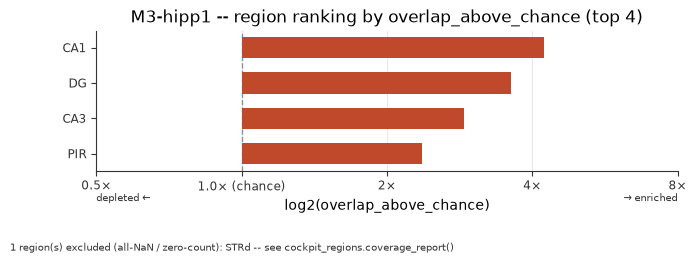

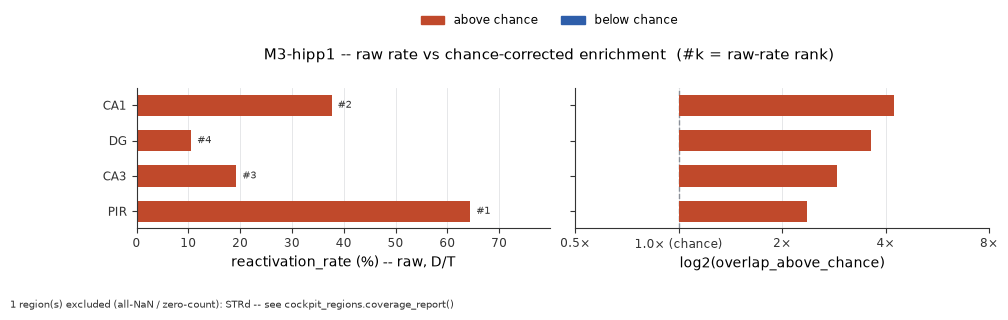

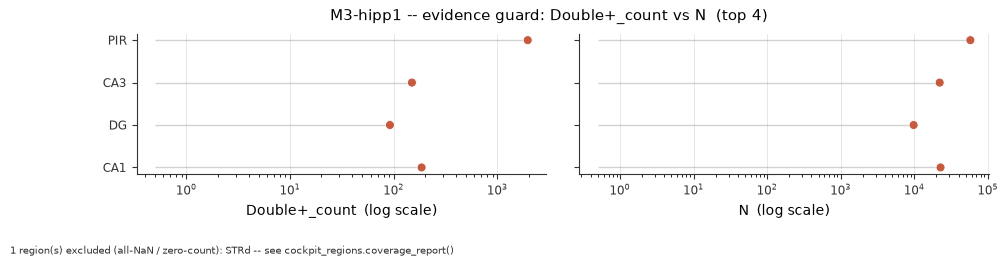

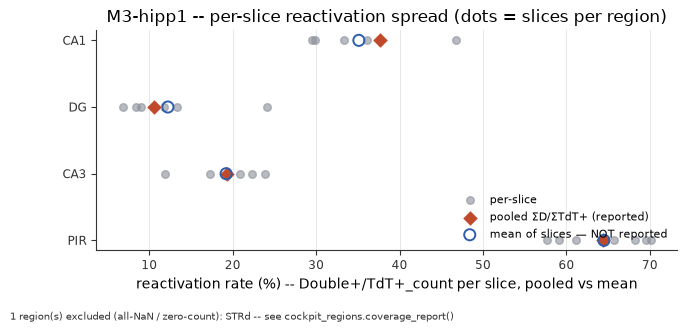

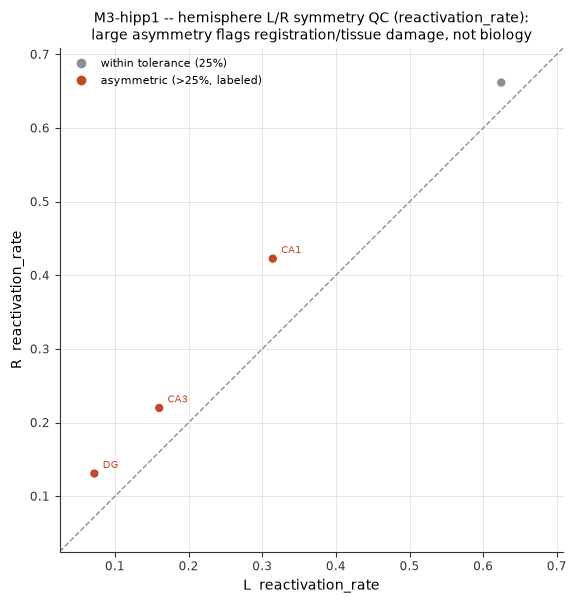

In [6]:
config0 = creg.load_pipeline_config(PROJECTS[0])
roles0 = ca.resolve_roles(config0, tagged=PARAMS["tagged_marker"],
                          activity=PARAMS["activity_marker"])

# Figure 4 (slice_spread) needs the per-slice readout -- only meaningful for a single
# project (D-8's pooled-vs-mean distinction is a per-animal, per-slice comparison).
per_slice = None
if len(PROJECTS) == 1:
    per_slice = creg.build_readout(PROJECTS[0], regions=PARAMS["regions"])
else:
    print("More than one project -- skipping figure 4 (slice_spread needs a single "
          "project's per-slice readout).")

figs = ca.build_figures(combined, config0, roles0, per_slice=per_slice,
                       top_n=PARAMS["top_n"], min_cells=PARAMS["min_cells"])

if PARAMS["save_figures"]:
    for p in ca.save_figures(figs, OUT_DIR):
        print(f"figure -> {p}")

for name, fig in figs.items():
    display(fig)
    plt.close(fig)


## 6. Caveat panel — the parked-gate / DAPI-dependence note

Every metric with N (DAPI-derived) in its denominator (`tagging_rate`, `activity_rate`,
`overlap_above_chance`, both `log2_odds_ratio` columns) inherits whatever DAPI over-detection
the white-matter/ventricle QC gates would have caught -- those gates are currently parked as
**advisory** (`cockpit_checks.GateThresholds.advisory_gates`). Inflated N deflates
`activity_rate` and therefore **inflates** `overlap_above_chance`. `reactivation_rate`,
`reverse_rate` and `jaccard` carry no N and are unaffected.

**Switching `--n-source`/`n_source` to `classifiable` does NOT fix this** -- on the M3 fixture
the classifiable joint population differs from the raw anchor (DAPI) count by only ~0.005%.
Classifiable filtering removes `Excluded` + non-finite bg-sub rows only; it does **not** remove
haze-detected nuclei. The actual levers: re-arm the white-matter gate, raise `k_robust`, or
lower `cellExpansionMicrons` -- named here so the number above is never read as if it were
already clean.

In [7]:
n_split = both.groupby("animal")["N_source"].value_counts().unstack(fill_value=0)
print("N_source split (both-hemisphere rows):")
display(n_split)

for animal, g in both.groupby("animal"):
    classif = g[g["N_source"] == "classifiable"]
    anchor_cols = [c for c in g.columns if c.endswith("_count") and "+" not in c and c != "N"]
    if len(classif) and anchor_cols:
        ratio = (classif["N"] / classif[anchor_cols[0]].replace(0, np.nan)).mean()
        if np.isfinite(ratio):
            print(f"  {animal}: classifiable/anchor ratio (mean) = {ratio:.4f}  "
                  f"-- confirms how little N moves (recon: ~0.005% on M3)")

N_source split (both-hemisphere rows):


N_source,classifiable
animal,
M3-hipp1,5


  M3-hipp1: classifiable/anchor ratio (mean) = 1.0000  -- confirms how little N moves (recon: ~0.005% on M3)
